In [3]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


## Preprocessing

In [4]:
def reduce_graph(G, target_size=20):
    # Step 1: Copy the graph
    G_reduced = G.copy()

    # Step 2: Remove self-loops
    self_loops = list(nx.selfloop_edges(G_reduced))
    G_reduced.remove_edges_from(self_loops)

    # Step 3: Remove leaves (degree 1) iteratively
    while G_reduced.number_of_nodes() > target_size:
        leaves = [n for n in G_reduced.nodes if G_reduced.degree(n) == 1]
        if not leaves:
            break
        G_reduced.remove_nodes_from(leaves)

    # Step 4: Remove lowest-degree nodes if still too large
    while G_reduced.number_of_nodes() > target_size:
        degree_list = sorted(G_reduced.degree, key=lambda x: x[1])
        if not degree_list:
            break
        node_to_remove = degree_list[0][0]
        G_reduced.remove_node(node_to_remove)

    return G_reduced

In [27]:
import pickle

path = "SophieVie/day_graphs/" # change the path accordingly

G = pickle.load(open(path + f"Graph_20", "rb")).to_undirected()
G = reduce_graph(G, target_size=45)

In [ ]:
G.number_of_nodes()

In [30]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


n_wires = G.number_of_nodes()
G=reduce_graph(G)
graph = list(G.edges)

# ==== STEP 2: MODULARITY MATRIX ====
def modularity_hamiltonian(G):
    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2 * m)

    coeffs = []
    obs = []
    for i in range(len(B)):
        for j in range(i+1, len(B)):
            if not np.isclose(B[i, j], 0.0):
                coeffs.append(B[i, j] / (4 * m))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return qml.Hamiltonian(coeffs, obs)

cost_h = modularity_hamiltonian(G)
mixer_h = qml.Hamiltonian([1.0] * n_wires, [qml.PauliX(i) for i in range(n_wires)])

# ==== STEP 3: QNODE ====
dev = qml.device("lightning.gpu", wires=n_wires)

def U_C(gamma):
    qml.templates.ApproxTimeEvolution(cost_h, gamma, 1)

def U_B(beta):
    qml.templates.ApproxTimeEvolution(mixer_h, beta, 1)

@qml.qnode(dev)
def circuit(gammas, betas, return_samples=False, return_probs=False):
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)
    for gamma, beta in zip(gammas, betas):
        U_C(gamma)
        U_B(beta)
    if return_samples:
        return qml.sample()
    elif return_probs:
        return qml.probs(wires=range(n_wires))
    return qml.expval(cost_h)

# ==== STEP 4: OBJECTIVE ====
def objective(params):
    gammas, betas = params
    return -circuit(gammas, betas)  # vogliamo massimizzare la modularità

# ==== STEP 5: QAOA ROUTINE ====
def qaoa_modularity(n_layers=1, steps=30):
    print(f"\n▶️ Run QAOA with p={n_layers}")
    init_params = 0.01 * np.random.rand(2, n_layers)
    init_params = np.array(init_params, requires_grad=True)

    opt = qml.AdagradOptimizer(stepsize=0.5)
    params = init_params
    best_params = params
    best_obj = objective(params)

    for i in range(steps):
        params = opt.step(objective, params)
        if -objective(params) < best_obj:
          best_obj = -objective(params)
          best_params = params
        if (i + 1) % 5 == 0:
            print(f"Step {i+1:02d}: modularity ≈ {-objective(params):.6f}")

    best_probs = circuit(params[0], params[1], return_probs=True)

    return best_probs

# ==== STEP 6: VISUALIZZAZIONE ====
def plot_communities(G, bitstring):
    color_map = ['red' if bit else 'blue' for bit in bitstring]
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=600, edge_color="gray")
    plt.title("Comunity found with QAOA")
    plt.show()


## Optimized method

In [31]:
def modularity_hamiltonian_sparsified(G, tau=0.0):
    """
    Build a sparsified modularity Hamiltonian.
    Keeps only matrix elements |B_ij| >= tau.

    Parameters
    ----------
    G : networkx.Graph
    tau : float
        Threshold for |B_ij|. Default=0.0 reproduces full modularity Hamiltonian.

    Returns
    -------
    qml.Hamiltonian
    """

    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2 * m)

    coeffs = []
    obs = []

    n = len(B)
    for i in range(n):
        for j in range(i + 1, n):
            Bij = B[i, j]
            if np.abs(Bij) >= tau:  # <-- threshold condition
                coeffs.append(float(Bij / (4 * m)))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))

    print(f"Sparsification: kept {len(coeffs)} ZZ terms out of {n*(n-1)//2}")
    return qml.Hamiltonian(coeffs, obs)


In [32]:
def modularity_hamiltonian_topK(G, keep_ratio=0.2):
    """
    Keep the top keep_ratio fraction of |B_ij| entries.
    Example: keep_ratio=0.2 keeps the strongest 20% couplings.

    Parameters
    ----------
    G : networkx.Graph
    keep_ratio : float in (0,1]

    Returns
    -------
    qml.Hamiltonian
    """

    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2*m)

    n = len(B)
    all_pairs = []
    for i in range(n):
        for j in range(i+1, n):
            all_pairs.append((i, j, np.abs(B[i, j])))

    # Sort by |Bij| descending
    all_pairs_sorted = sorted(all_pairs, key=lambda x: x[2], reverse=True)

    # Determine cutoff
    K = int(keep_ratio * len(all_pairs_sorted))
    selected_pairs = set((i, j) for (i, j, _) in all_pairs_sorted[:K])

    coeffs, obs = [], []
    for (i, j) in selected_pairs:
        coeffs.append(B[i, j] / (4 * m))
        obs.append(qml.PauliZ(i) @ qml.PauliZ(j))

    print(f"Top-K sparsification: kept {len(coeffs)} terms out of {n*(n-1)//2}")
    return qml.Hamiltonian(coeffs, obs)


In [33]:
def modularity_hamiltonian_energy_preserving(G, energy_ratio=0.9):
    """
    Keep entries until cumulative |B_ij|^2 covers energy_ratio of the Frobenius norm.

    Parameters
    ----------
    G : networkx.Graph
    energy_ratio : float in (0,1]

    Returns
    -------
    qml.Hamiltonian
    """

    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2*m)

    n = len(B)
    entries = []
    for i in range(n):
        for j in range(i+1, n):
            entries.append((i, j, B[i,j], B[i,j]**2))

    # sort by squared magnitude
    entries_sorted = sorted(entries, key=lambda x: x[3], reverse=True)

    total_energy = sum(x[3] for x in entries_sorted)
    acc_energy  = 0
    selected = []

    for (i, j, Bij, e2) in entries_sorted:
        selected.append((i, j, Bij))
        acc_energy += e2
        if acc_energy >= energy_ratio * total_energy:
            break

    coeffs = [Bij / (4*m) for (i,j,Bij) in selected]
    obs = [qml.PauliZ(i) @ qml.PauliZ(j) for (i,j,Bij) in selected]

    print(f"Energy sparsification: kept {len(coeffs)} ZZ terms, energy covered: {acc_energy/total_energy:.2%}")

    return qml.Hamiltonian(coeffs, obs)


In [34]:
def modularity_hamiltonian_lowrank(G, k_rank=1):
    """
    Low-rank (spectral) approximation of the modularity Hamiltonian.
    Approximates B ≈ U_k Λ_k U_k^T using the top-k eigenpairs.

    Parameters
    ----------
    G : networkx.Graph
    k_rank : int
        Number of leading eigenvectors/eigenvalues to keep.
        k_rank=1 gives the dominant modularity signal.

    Returns
    -------
    qml.Hamiltonian
    """

    # ---- Build modularity matrix ----
    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2 * m)

    # ---- Spectral decomposition ----
    # eigh returns eigenvalues sorted low -> high, so take largest k
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]   # descending order
    eigvals = eigvals[idx][:k_rank]
    eigvecs = eigvecs[:, idx][:, :k_rank]

    # ---- Build low-rank approximation ----
    Bk = eigvecs @ np.diag(eigvals) @ eigvecs.T  # U_k Λ_k U_k^T

    # ---- Convert Bk into Hamiltonian ----
    coeffs = []
    obs = []
    n = len(B)

    kept = 0
    for i in range(n):
        for j in range(i+1, n):
            Bij = Bk[i, j]
            #use EPS = 1e-3 for all tests excpet noise test
            #EPS = 1e-3  # try 1e-3 if still empty
            EPS = 1e-2  # try 1e-3 if still empty
            if abs(Bij) > EPS:
            #if not np.isclose(Bij, 0.0):
                coeffs.append(Bij / (4 * m))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                kept += 1

    print(f"Low-rank projection: kept {kept} ZZ terms from rank-{k_rank} spectral model")

    return qml.Hamiltonian(coeffs, obs)


In [35]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx

def modularity_hamiltonian_with_penalty(G, mu=0.0, S=0):
    """
    Build modularity Hamiltonian augmented with a penalty term:
        H = H_modularity - mu * (sum_i Z_i - S)^2

    Parameters
    ----------
    G : networkx.Graph
    mu : float
        Penalty strength (default 0.0 = no penalty).
    S : int or float
        Desired sum of Z eigenvalues (sum_i z_i). For a balanced binary split use S = 0.

    Returns
    -------
    qml.Hamiltonian
    """
    # ---- Build modularity matrix B ----
    A = nx.to_numpy_array(G)
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    if m == 0:
        raise ValueError("Graph has no edges (m == 0).")
    B = A - np.outer(k, k) / (2 * m)

    n = len(B)

    # We'll accumulate coefficients for ZZ pairs and Z singles
    zz_coeff = {}   # key: (i,j) with i<j -> coeff
    z_coeff = {}    # key: i -> coeff

    # --- Start with modularity ZZ contributions ---
    for i in range(n):
        for j in range(i + 1, n):
            Bij = float(B[i, j])
            if not np.isclose(Bij, 0.0):
                # modularity uses Bij/(4m) as in your original code
                zz_coeff[(i, j)] = zz_coeff.get((i, j), 0.0) + Bij / (4.0 * m)

    # --- Add penalty expansion contributions ---
    # Expand: -mu*(sum_i Z_i - S)^2
    # = -mu*( sum_i Z_i^2 + 2 sum_{i<j} Z_i Z_j - 2 S sum_i Z_i + S^2 )
    # Z_i^2 = I -> constant (ignored)
    # ZZ pairs contribution: -mu * 2 * Z_i Z_j  -> coefficient -2*mu for each pair
    # single-Z contribution: -mu * (-2 S) * Z_i = +2 * mu * S
    if mu != 0.0:
        pair_pen = -2.0 * mu
        for i in range(n):
            for j in range(i + 1, n):
                zz_coeff[(i, j)] = zz_coeff.get((i, j), 0.0) + pair_pen

        single_pen = 2.0 * mu * S
        for i in range(n):
            z_coeff[i] = z_coeff.get(i, 0.0) + single_pen

    # ---- Convert accumulated coefficients into qml.Hamiltonian ----
    coeffs = []
    ops = []

    # Add ZZ terms
    for (i, j), c in zz_coeff.items():
        if not np.isclose(c, 0.0):
            coeffs.append(float(c))
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

    # Add single Z terms
    for i, c in z_coeff.items():
        if not np.isclose(c, 0.0):
            coeffs.append(float(c))
            ops.append(qml.PauliZ(i))

    # (Optional) you can include the constant term if desired:
    # const = -mu * (n + S**2)  # from expansion: -mu*(N + S^2)  (but usually unnecessary)
    # if you want it: coeffs.append(const); ops.append(qml.Identity(wires=[]))

    kept_zz = sum(1 for k in zz_coeff if not np.isclose(zz_coeff[k], 0.0))
    kept_z = sum(1 for k in z_coeff if not np.isclose(z_coeff[k], 0.0))
    total_pairs = n * (n - 1) // 2
    print(f"Penalty Hamiltonian: kept {kept_zz}/{total_pairs} ZZ terms and {kept_z}/{n} Z terms (mu={mu}, S={S})")

    if len(coeffs) == 0:
        # Avoid returning an empty Hamiltonian
        return qml.Hamiltonian([0.0], [qml.Identity(0)])
    return qml.Hamiltonian(coeffs, ops)


## Experiment Settings

### metrics and utilities

In [36]:
import networkx as nx
import io
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import numpy as np
import pandas as pd
import math
import os, random
import tensorflow as tf
from sklearn.cluster import KMeans
from sklearn import metrics, preprocessing
from collections import Counter
import networkx.algorithms.community as nx_comm

In [37]:
def reduce_graph(G, target_size=20):
    # Step 1: Copy the graph
    G_reduced = G.copy()

    # Step 2: Remove self-loops
    self_loops = list(nx.selfloop_edges(G_reduced))
    G_reduced.remove_edges_from(self_loops)

    # Step 3: Remove leaves (degree 1) iteratively
    while G_reduced.number_of_nodes() > target_size:
        leaves = [n for n in G_reduced.nodes if G_reduced.degree(n) == 1]
        if not leaves:
            break
        G_reduced.remove_nodes_from(leaves)

    # Step 4: Remove lowest-degree nodes if still too large
    while G_reduced.number_of_nodes() > target_size:
        degree_list = sorted(G_reduced.degree, key=lambda x: x[1])
        if not degree_list:
            break
        node_to_remove = degree_list[0][0]
        G_reduced.remove_node(node_to_remove)

    return G_reduced

In [38]:
def compute_modularity_safe(G, quantum_partition):
    community_0 = {n for n, c in quantum_partition.items() if c == 0}
    community_1 = {n for n, c in quantum_partition.items() if c == 1}

    # Check if either community is empty
    if not community_0 or not community_1:
        return 0.0

    modularity = nx.algorithms.community.quality.modularity(G, [community_0, community_1])
    return modularity

In [39]:
from sklearn.cluster import KMeans
import numpy as np

def binary_partition(partition, G):
    """
    Reduces a multi-community partition to a binary (2-community) one
    using KMeans clustering on the original Louvain labels.

    Parameters:
        partition (dict): Original Louvain partition {node: community_label}.
        G (networkx.Graph): The corresponding graph.

    Returns:
        dict: New partition with only two communities {node: 0 or 1}.
    """
    nodes = list(G.nodes())
    original_labels = np.array([partition[node] for node in nodes]).reshape(-1, 1)

    kmeans = KMeans(n_clusters=2, n_init='auto').fit(original_labels)
    binary_labels = kmeans.labels_

    partition_binary = {node: int(label) for node, label in zip(nodes, binary_labels)}
    return partition_binary


In [40]:
def compute_conductance(G, partition):
    cut_edges = 0
    volume = {0: 0, 1: 0}
    for u, v in G.edges():
        pu, pv = partition[u], partition[v]
        if pu != pv:
            cut_edges += 1
        volume[pu] += 1
        volume[pv] += 1
    return cut_edges / min(volume[0], volume[1]) if min(volume[0], volume[1]) > 0 else 0

def compute_cut_ratio(G, partition):
    cut_edges = sum(1 for u, v in G.edges() if partition[u] != partition[v])
    total_possible_cut = len(partition) * (len(partition) - 1) / 2
    return cut_edges / total_possible_cut if total_possible_cut > 0 else 0

def compute_coverage(G, partition):
    intra_edges = sum(1 for u, v in G.edges() if partition[u] == partition[v])
    return intra_edges / G.number_of_edges() if G.number_of_edges() > 0 else 0


## Experiment 1: benchmark with seeds

In [41]:
# === Cell 1: Imports, config, helpers, and metrics initialization ===

import community.community_louvain as community_louvain
from pennylane import numpy as np
import pennylane as qml
import pickle
import matplotlib.pyplot as plt
import time
import os

# ------------------ CONFIG -------------------
graph_num = 63
num_layers = 2
n_steps = 80

n_seeds = 5
base_seed = 1234


# Bad Accuracy -, performance +
threshold = 0.06
lowrank_k = 1
topK_ratio = 0.5
penalty_mu = 2.5
penalty_S = 0
energy_ratio = 0.5

# Best Accuracy +, performance -
threshold = 0.01
lowrank_k = 3
topK_ratio = 1.0
penalty_mu = 0.0
penalty_S = 0
energy_ratio = 0.9

# Mid conf
threshold = 0.03
lowrank_k = 2
topK_ratio = 0.7
penalty_mu = 1.0
penalty_S = 0
energy_ratio = 0.6

# ------------------ METHODS -------------------
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK",
    "qaoa_penalty"
]

# ------------------ METRICS -------------------
metrics = {
    "modularity": {m: [] for m in ["classical"] + methods},
    "conductance": {m: [] for m in ["classical"] + methods},
    "cut_ratio": {m: [] for m in ["classical"] + methods},
    "coverage": {m: [] for m in ["classical"] + methods},
    "runtime": {m: [] for m in methods},
}

# ======================================
# QAOA runner factory
# ======================================
def build_qaoa_runner(G, cost_h, mixer_h, n_wires):

    dev = qml.device("lightning.gpu", wires=n_wires)
    #dev = qml.device('qiskit.aer', wires=n_wires, backend=AerSimulator(), method="automatic")

    def U_C(gamma):
        qml.templates.ApproxTimeEvolution(cost_h, gamma, 1)

    def U_B(beta):
        qml.templates.ApproxTimeEvolution(mixer_h, beta, 1)

    @qml.qnode(dev)
    def circuit(gammas, betas, return_probs=False):
        for w in range(n_wires):
            qml.Hadamard(wires=w)
        for gamma, beta in zip(gammas, betas):
            U_C(gamma)
            U_B(beta)
        if return_probs:
            return qml.probs(wires=range(n_wires))
        return qml.expval(cost_h)

    def objective(params):
        g, b = params
        return -circuit(g, b)

    def run_qaoa(seed):
        np.random.seed(seed)
        #params = np.array(0.01 * np.random.rand(2, num_layers), requires_grad=True)
        params = np.random.uniform(0.01 * np.random.rand(2, num_layers), requires_grad=True)
        opt = qml.AdagradOptimizer(stepsize=0.5)

        t0 = time.time()
        for step in range(n_steps):
            params = opt.step(objective, params)
        runtime = time.time() - t0

        probs = circuit(params[0], params[1], return_probs=True)
        return probs, runtime

    return run_qaoa

print("Setup complete.")


Setup complete.


In [44]:
num_nodes_red = 20
st_node = 56
end_node = 63

In [ ]:
# === Cell 2: Process Graphs 0–9 with Multiple Seeds ===

# Uncomment this if resuming
#metrics = pickle.load(open("metrics_partial.pkl", "rb"))

# ------------------ Seed config ------------------
seeds = list(range(1, 11))

for graph_id in range(st_node, end_node):

    print(f"\n================== GRAPH {graph_id} ==================")

    # ------------------ Load and reduce graph ------------------
    G = pickle.load(open(path + f"Graph_{graph_id}", "rb")).to_undirected()
    G = reduce_graph(G, target_size=num_nodes_red)

    # ------------------ Classical baseline ------------------
    part = community_louvain.best_partition(G)
    part = binary_partition(part, G)

    metrics["modularity"]["classical"].append(community_louvain.modularity(part, G))
    metrics["conductance"]["classical"].append(compute_conductance(G, part))
    metrics["cut_ratio"]["classical"].append(compute_cut_ratio(G, part))
    metrics["coverage"]["classical"].append(compute_coverage(G, part))

    # ------------------ Qubits ------------------
    node_to_qubit = {n: i for i, n in enumerate(G.nodes())}
    qubit_to_node = {i: n for n, i in node_to_qubit.items()}
    n_wires = G.number_of_nodes()
    mixer_h = qml.Hamiltonian([1.0]*n_wires, [qml.PauliX(i) for i in range(n_wires)])

    # ------------------ Cost Hamiltonians ------------------
    quantum_costs = {
        "qaoa_full":    modularity_hamiltonian(G),
        "qaoa_sparse":  modularity_hamiltonian_sparsified(G, tau=threshold),
        "qaoa_lowrank": modularity_hamiltonian_lowrank(G, k_rank=lowrank_k),
        "qaoa_energy_based": modularity_hamiltonian_energy_preserving(G, energy_ratio=energy_ratio),
        "qaoa_topK":    modularity_hamiltonian_topK(G, keep_ratio=topK_ratio),
        "qaoa_penalty": modularity_hamiltonian_with_penalty(G, mu=penalty_mu, S=penalty_S),
    }

    # ------------------ QAOA Runs with multiple seeds ------------------
    for method, cost_h in quantum_costs.items():
        print(f" → Running {method} QAOA...")

        runner = build_qaoa_runner(G, cost_h, mixer_h, n_wires)

        # Lists to store metrics over seeds
        mod_list = []
        cond_list = []
        cut_list = []
        cov_list = []
        runtime_list = []

        for s in seeds:
            #seed = base_seed + s
            probs, runtime = runner(s)
            runtime_list.append(runtime)

            # Find best bitstring
            best = max([(format(i, f"0{n_wires}b"), p) for i, p in enumerate(probs)],
                       key=lambda x: x[1])[0]

            part_q = {qubit_to_node[q]: int(bit) for q, bit in enumerate(best)}
            # Compute metrics
            mod_list.append(compute_modularity_safe(G, part_q))
            cond_list.append(compute_conductance(G, part_q))
            cut_list.append(compute_cut_ratio(G, part_q))
            cov_list.append(compute_coverage(G, part_q))

        # Append aggregated results **after all seeds**
        metrics["runtime"][method].append(runtime_list)
        metrics["modularity"][method].append(mod_list)
        metrics["conductance"][method].append(cond_list)
        metrics["cut_ratio"][method].append(cut_list)
        metrics["coverage"][method].append(cov_list)
    # ------------------ Save partial metrics ------------------
    pickle.dump(metrics, open("metrics_partial.pkl", "wb"))
    print("Saved metrics for graphs "+str(st_node)+"_"+str(end_node))


================== GRAPH 56 ==================
Sparsification: kept 190 ZZ terms out of 190
Low-rank projection: kept 185 ZZ terms from rank-2 spectral model
Energy sparsification: kept 32 ZZ terms, energy covered: 61.25%
Top-K sparsification: kept 133 terms out of 190
Penalty Hamiltonian: kept 190/190 ZZ terms and 0/20 Z terms (mu=1.0, S=0)
 → Running qaoa_full QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_sparse QAOA...
 → Running qaoa_lowrank QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_energy_based QAOA...


...

 → Running qaoa_energy_based QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_topK QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_penalty QAOA...
Saved metrics for graphs 56_63


### means and CIs

In [46]:
import numpy as np

def compute_mean_ci(metrics, methods, z=1.96):
    metrics_mean = {}
    metrics_ci = {}

    for metric in metrics:
        metrics_mean[metric] = {}
        metrics_ci[metric] = {}

        for method in metrics[metric]:
            means = []
            cis = []

            for values in metrics[metric][method]:
                values = np.array(values)

                # Handle classical (already scalar)
                if values.ndim == 0 or len(values.shape) == 0:
                    mean = values
                    ci = 0.0
                elif len(values) == 1:
                    mean = values[0]
                    ci = 0.0
                else:
                    mean = np.mean(values)
                    std = np.std(values, ddof=1)
                    ci = z * std / np.sqrt(len(values))

                means.append(mean)
                cis.append(ci)

            metrics_mean[metric][method] = means
            metrics_ci[metric][method] = cis

    return metrics_mean, metrics_ci


metrics_mean, metrics_ci = compute_mean_ci(metrics, methods)

In [47]:
import matplotlib.pyplot as plt

def plot_metric(metric, ylabel):
    x = range(len(metrics_mean[metric]["classical"]))
    plt.figure(figsize=(10,5))

    # Classical baseline (no CI)
    plt.plot(x, metrics_mean[metric]["classical"],
             label="Classical Louvain", linewidth=2, marker='o')

    # QAOA methods with CI
    for m in methods:
        y = metrics_mean[metric][m]
        yerr = metrics_ci[metric][m]

        plt.errorbar(x, y, yerr=yerr,
                     label=m, linewidth=2,
                     marker='o', capsize=4)

    # Formatting
    plt.xlabel("Graph index", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [48]:
def plot_runtime():
    x = range(len(metrics_mean["runtime"]["qaoa_full"]))
    plt.figure(figsize=(10,5))

    for m in methods:
        y = metrics_mean["runtime"][m]
        yerr = metrics_ci["runtime"][m]

        plt.errorbar(x, y, yerr=yerr,
                     label=f"{m} runtime",
                     linewidth=2, marker='o', capsize=4)

    plt.xlabel("Graph index", fontsize=18)
    plt.ylabel("Runtime (seconds)", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
for m in methods:
    if m in metrics_mean["modularity"]:
        print(m, len(metrics_mean["modularity"][m]))
print(m, len(metrics_mean["modularity"]["classical"]))

qaoa_full 63
qaoa_sparse 63
qaoa_lowrank 63
qaoa_energy_based 63
qaoa_topK 63
qaoa_penalty 63
qaoa_penalty 63


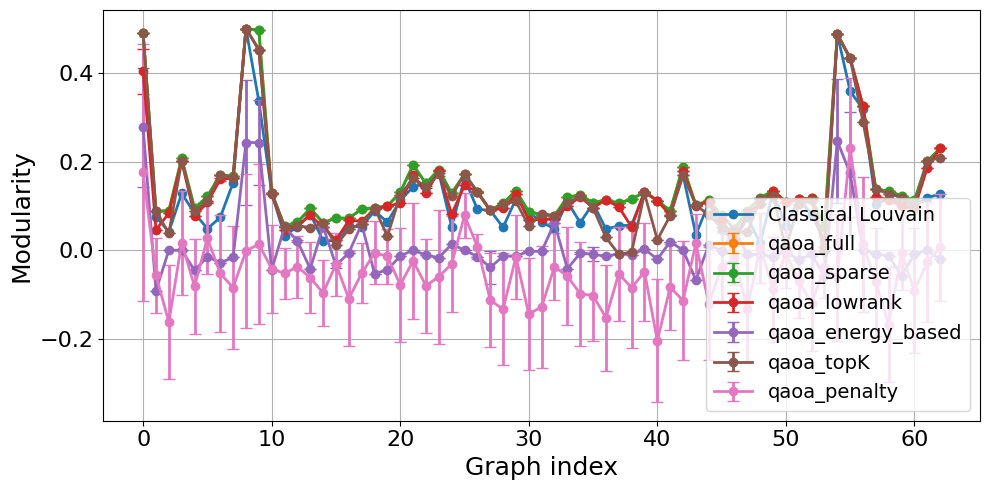

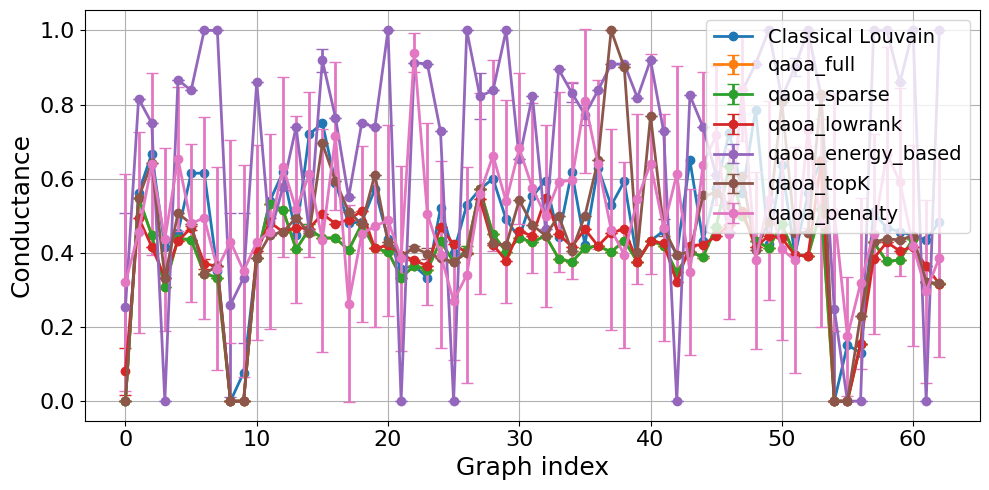

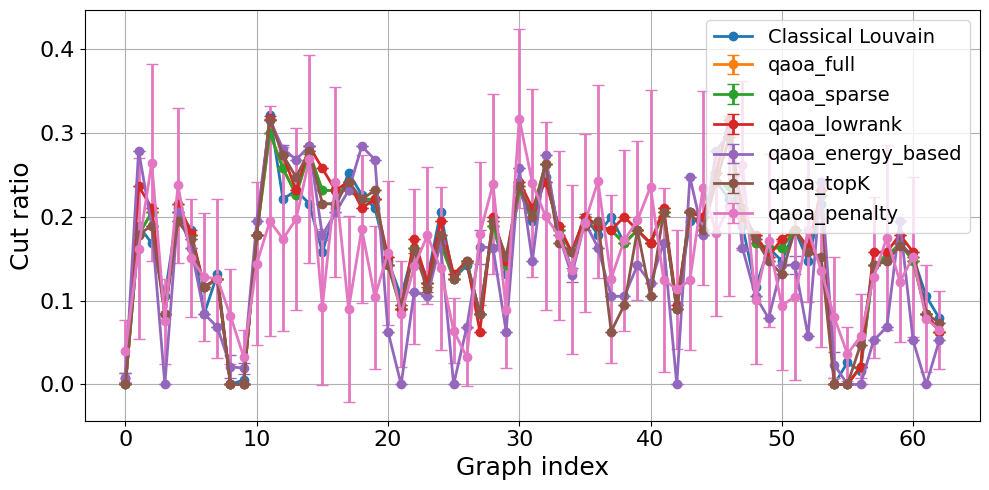

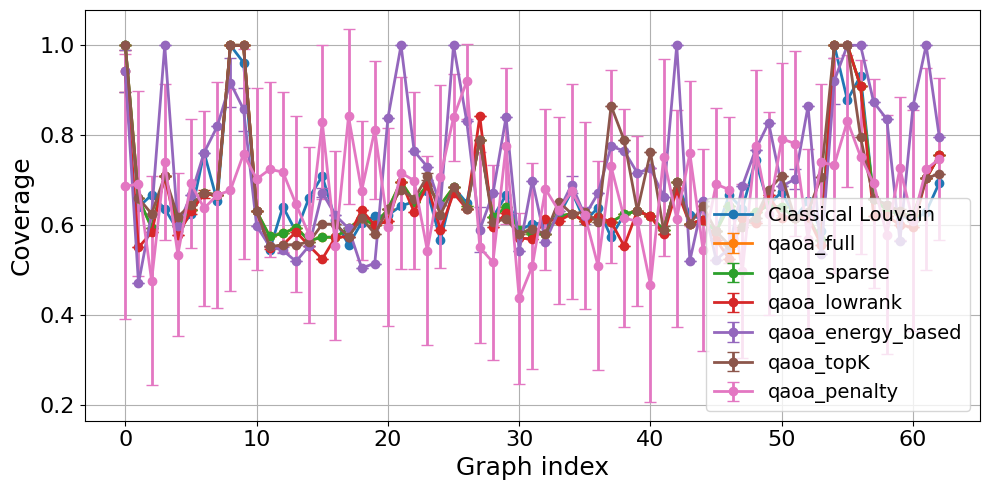

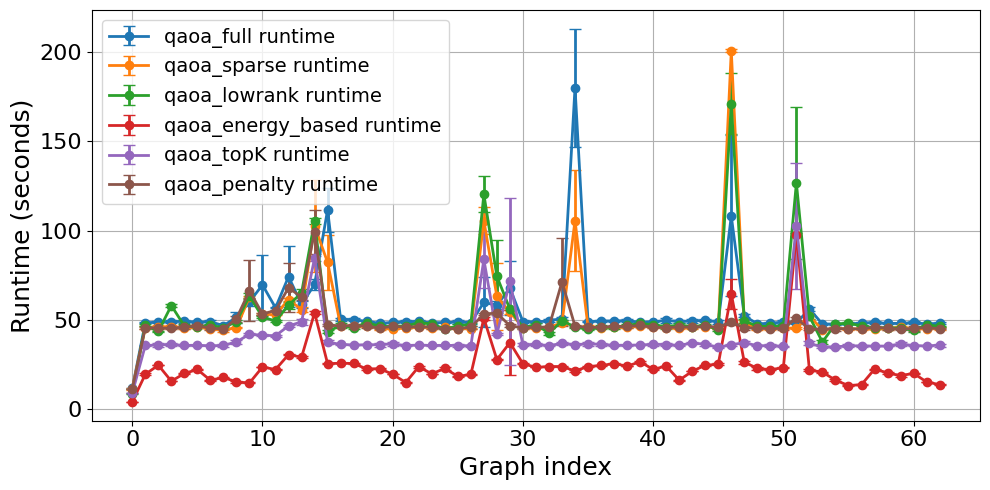

All plots generated.


In [ ]:
plot_metric("modularity", "Modularity")
plot_metric("conductance", "Conductance")
plot_metric("cut_ratio", "Cut ratio")
plot_metric("coverage", "Coverage")
plot_runtime()

print("All plots generated.")

# Experiment 2: Scalability test on dense graphs

In [ ]:
import networkx as nx
import pickle

graph_num = 63
num_nodes_red = 26   # reduced graph size
sub_g_nodes = 10

densities = []

for graph_id in range(graph_num):
    G = pickle.load(open(path + f"Graph_{graph_id}", "rb")).to_undirected()

    # Apply your reduction
    G_sub = reduce_graph(G, target_size=num_nodes_red)

    # Compute density
    d = nx.density(G_sub)
    densities.append((graph_id, d))

# sort descending
densities_sorted = sorted(densities, key=lambda x: x[1], reverse=True)
top_dense_graphs = [idx for idx, _ in densities_sorted[:sub_g_nodes]]
top_dense_graphs = sorted(top_dense_graphs)

print("Top 10 dense reduced graphs:", top_dense_graphs)


Top 10 dense reduced graphs: [11, 12, 14, 15, 17, 18, 30, 32, 45, 46]


In [ ]:
print("=== Top Dense Subgraphs ===")
for gid, d in densities_sorted[:sub_g_nodes]:
    print(f"Graph {gid:2d}  →  density = {d:.4f}")

=== Top Dense Subgraphs ===
Graph 11  →  density = 0.6431
Graph 46  →  density = 0.5969
Graph 32  →  density = 0.5754
Graph 14  →  density = 0.5692
Graph 12  →  density = 0.5631
Graph 45  →  density = 0.5354
Graph 17  →  density = 0.4985
Graph 18  →  density = 0.4923
Graph 30  →  density = 0.4923
Graph 15  →  density = 0.4892


In [ ]:
# === stress test ===

import community.community_louvain as community_louvain
from pennylane import numpy as np
import pennylane as qml
import pickle
import matplotlib.pyplot as plt
import time
import os

# ------------------ CONFIG -------------------
graph_num = 63
num_layers = 2
n_steps = 5



# Best Accuracy +, performance -
threshold = 0.4
lowrank_k = 1
topK_ratio = 0.5
penalty_mu = 0.4
penalty_S = 0
energy_ratio = 0.7





# ------------------ METHODS -------------------
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK",
    "qaoa_penalty"
]

# ------------------ METRICS -------------------
metrics = {
    "modularity": {m: [] for m in ["classical"] + methods},
    "conductance": {m: [] for m in ["classical"] + methods},
    "cut_ratio": {m: [] for m in ["classical"] + methods},
    "coverage": {m: [] for m in ["classical"] + methods},
    "runtime": {m: [] for m in methods},
}

# ------------------ SEEDS -------------------
#seeds = list(range(20))   # same as main experiment
seeds = list(range(5))   # same as main experiment

# ======================================
# QAOA runner factory
# ======================================
def build_qaoa_runner(G, cost_h, mixer_h, n_wires):

    dev = qml.device("lightning.gpu", wires=n_wires)

    def U_C(gamma):
        qml.templates.ApproxTimeEvolution(cost_h, gamma, 1)

    def U_B(beta):
        qml.templates.ApproxTimeEvolution(mixer_h, beta, 1)

    @qml.qnode(dev)
    def circuit(gammas, betas, return_probs=False):
        for w in range(n_wires):
            qml.Hadamard(wires=w)
        for gamma, beta in zip(gammas, betas):
            U_C(gamma)
            U_B(beta)
        if return_probs:
            return qml.probs(wires=range(n_wires))
        return qml.expval(cost_h)

    def objective(params):
        g, b = params
        return -circuit(g, b)

    def run_qaoa(seed):
        np.random.seed(seed)

        params = np.array(0.01 * np.random.rand(2, num_layers), requires_grad=True)
        opt = qml.AdagradOptimizer(stepsize=0.5)

        t0 = time.time()
        for step in range(n_steps):
            params = opt.step(objective, params)
        runtime = time.time() - t0

        probs = circuit(params[0], params[1], return_probs=True)
        return probs, runtime

    return run_qaoa


In [ ]:
num_nodes_red = 11

In [ ]:
# ------------------ SELECT SINGLE GRAPH ------------------

# Choose which index in top_dense_graphs to run
target_idx = 1   # change this (0 → first, 1 → second, etc.)

# Create a temporary list with only one graph
overall_top_dense_graphs = top_dense_graphs
#top_dense_graphs = [overall_top_dense_graphs[target_idx]]

top_dense_graphs = overall_top_dense_graphs[:10]

print("Running only graph:", top_dense_graphs)

Running only graph: [11, 12, 14, 15, 17, 18, 30, 32, 45, 46]


In [ ]:
# Comment this if first run
#metrics = pickle.load(open("metrics_dense_subgraphs_top10.pkl", "rb"))
#metrics = pickle.load(open("metrics_dense_subgraphs_top10_noiseless.pkl", "rb"))

for graph_id in top_dense_graphs:

    print(f"\n================== GRAPH {graph_id} ==================")

    G = pickle.load(open(path + f"Graph_{graph_id}", "rb")).to_undirected()
    G = reduce_graph(G, target_size=num_nodes_red)

    # Classical Louvain
    part = community_louvain.best_partition(G)
    part = binary_partition(part, G)

    metrics["modularity"]["classical"].append(community_louvain.modularity(part, G))
    metrics["conductance"]["classical"].append(compute_conductance(G, part))
    metrics["cut_ratio"]["classical"].append(compute_cut_ratio(G, part))
    metrics["coverage"]["classical"].append(compute_coverage(G, part))

    # qubit mapping
    node_to_qubit = {n: i for i, n in enumerate(G.nodes())}
    qubit_to_node = {i: n for n, i in node_to_qubit.items()}
    n_wires = G.number_of_nodes()

    mixer_h = qml.Hamiltonian([1.0]*n_wires, [qml.PauliX(i) for i in range(n_wires)])

    # define cost Hamiltonians
    quantum_costs = {
        "qaoa_full":    modularity_hamiltonian(G),
        "qaoa_sparse":  modularity_hamiltonian_sparsified(G, tau=threshold),
        "qaoa_lowrank": modularity_hamiltonian_lowrank(G, k_rank=lowrank_k),
        "qaoa_energy_based": modularity_hamiltonian_energy_preserving(G, energy_ratio=energy_ratio),
        "qaoa_topK":    modularity_hamiltonian_topK(G, keep_ratio=topK_ratio),
        "qaoa_penalty": modularity_hamiltonian_with_penalty(G, mu=penalty_mu, S=penalty_S),
    }

    for method, cost_h in quantum_costs.items():
        print(f" → Running {method} QAOA...")

        runner = build_qaoa_runner(G, cost_h, mixer_h, n_wires)

        # store per-seed results
        mod_list, cond_list, cut_list, cov_list, runtime_list = [], [], [], [], []

        for s in seeds:
            probs, runtime = runner(s)
            runtime_list.append(runtime)

            best = max([(format(i, f"0{n_wires}b"), p) for i, p in enumerate(probs)],
                   key=lambda x: x[1])[0]

            part_q = {qubit_to_node[q]: int(bit) for q, bit in enumerate(best)}

            mod_list.append(compute_modularity_safe(G, part_q))
            cond_list.append(compute_conductance(G, part_q))
            cut_list.append(compute_cut_ratio(G, part_q))
            cov_list.append(compute_coverage(G, part_q))

        # store lists (NOT scalars)
        metrics["runtime"][method].append(runtime_list)
        metrics["modularity"][method].append(mod_list)
        metrics["conductance"][method].append(cond_list)
        metrics["cut_ratio"][method].append(cut_list)
        metrics["coverage"][method].append(cov_list)

#pickle.dump(metrics, open("metrics_dense_subgraphs_top10.pkl", "wb"))
pickle.dump(metrics, open("metrics_dense_subgraphs_top10_noiseless.pkl", "wb"))
print("Saved metrics for densest reduced graphs.")



================== GRAPH 11 ==================
Sparsification: kept 7 ZZ terms out of 55
Low-rank projection: kept 22 ZZ terms from rank-1 spectral model
Energy sparsification: kept 10 ZZ terms, energy covered: 70.52%
Top-K sparsification: kept 27 terms out of 55
Penalty Hamiltonian: kept 55/55 ZZ terms and 0/11 Z terms (mu=0.4, S=0)
 → Running qaoa_full QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_sparse QAOA...
 → Running qaoa_lowrank QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_energy_based QAOA...


...

 → Running qaoa_energy_based QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_topK QAOA...


/home/danilo-cavaliere/PL_gpu_env/lib/python3.10/site-packages/pennylane/devices/preprocess.py:289: UserWarning: Differentiating with respect to the input parameters of LinearCombination is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(


 → Running qaoa_penalty QAOA...
Saved metrics for densest reduced graphs.


In [ ]:
metrics

{'modularity': {'classical': [0.015407986111111077, 0.019199567333693907],
  'qaoa_full': [[0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116],
   [0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144]],
  'qaoa_sparse': [[0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116],
   [0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583]],
  'qaoa_lowrank': [[-0.021701388888888853,
    -0.021701388888888853,
    -0.021701388888888853,
    -0.021701388888888853,
    -0.021701388888888853],
   [0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583,
    0.03244997295835583]],
  'qaoa_energy_based': [[0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.0154079861

In [ ]:
# ------------------ METHODS -------------------
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK",
    "qaoa_penalty"
]

metrics = pickle.load(open("metrics_dense_subgraphs_top10.pkl", "rb"))

In [ ]:
import numpy as np

def compute_mean_ci(metrics, methods, z=1.96):
    metrics_mean = {}
    metrics_ci = {}

    for metric in metrics:
        metrics_mean[metric] = {}
        metrics_ci[metric] = {}

        for method in metrics[metric]:
            means, cis = [], []

            for values in metrics[metric][method]:
                values = np.array(values)

                # classical case (scalar)
                if values.ndim == 0 or len(values.shape) == 0:
                    mean = values
                    ci = 0.0
                elif len(values) == 1:
                    mean = values[0]
                    ci = 0.0
                else:
                    mean = np.mean(values)
                    std = np.std(values, ddof=1)
                    ci = z * std / np.sqrt(len(values))

                means.append(mean)
                cis.append(ci)

            metrics_mean[metric][method] = means
            metrics_ci[metric][method] = cis

    return metrics_mean, metrics_ci


metrics_mean, metrics_ci = compute_mean_ci(metrics, methods)

In [ ]:
metrics

{'modularity': {'classical': [0.015407986111111077],
  'qaoa_full': [[0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116]],
  'qaoa_sparse': [[0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611

In [ ]:
metrics_ci

{'modularity': {'classical': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0],
  'qaoa_full': [np.float64(3.120107216941094e-18),
   np.float64(0.03458549899133736),
   np.float64(6.240214433882188e-18),
   np.float64(6.240214433882188e-18),
   np.float64(6.240214433882188e-18),
   np.float64(4.087636051394886e-05),
   np.float64(0.0),
   np.float64(6.240214433882188e-18),
   np.float64(1.2480428867764376e-17),
   np.float64(3.120107216941094e-18)],
  'qaoa_sparse': [np.float64(0.0),
   np.float64(3.120107216941094e-18),
   np.float64(0.0),
   np.float64(0.0),
   np.float64(6.240214433882188e-18),
   np.float64(1.2480428867764376e-17),
   np.float64(0.0),
   np.float64(6.240214433882188e-18),
   np.float64(0.0003891662901867369),
   np.float64(3.120107216941094e-18)],
  'qaoa_lowrank': [np.float64(0.0),
   np.float64(0.0009423716916230242),
   np.float64(0.0),
   np.float64(3.120107216941094e-18),
   np.float64(1.2480428867764376e-17),
   np.float64(1.24804

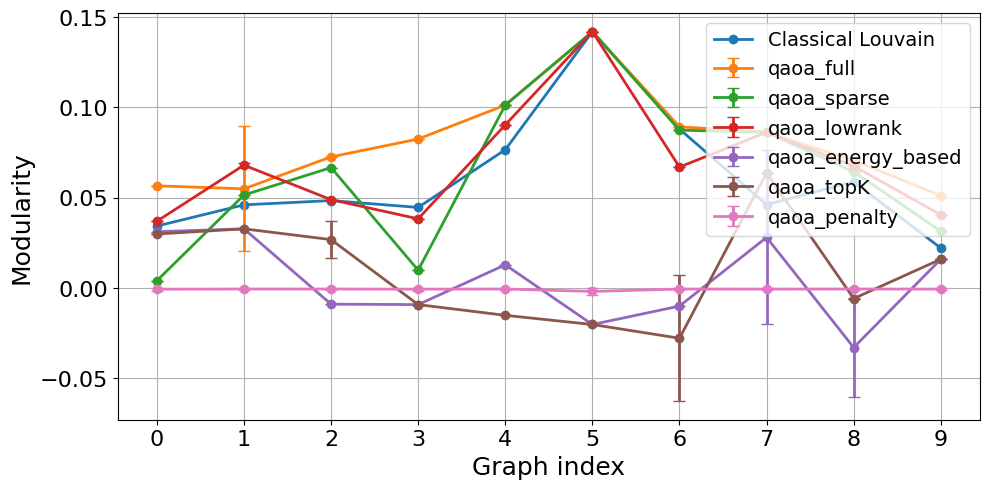

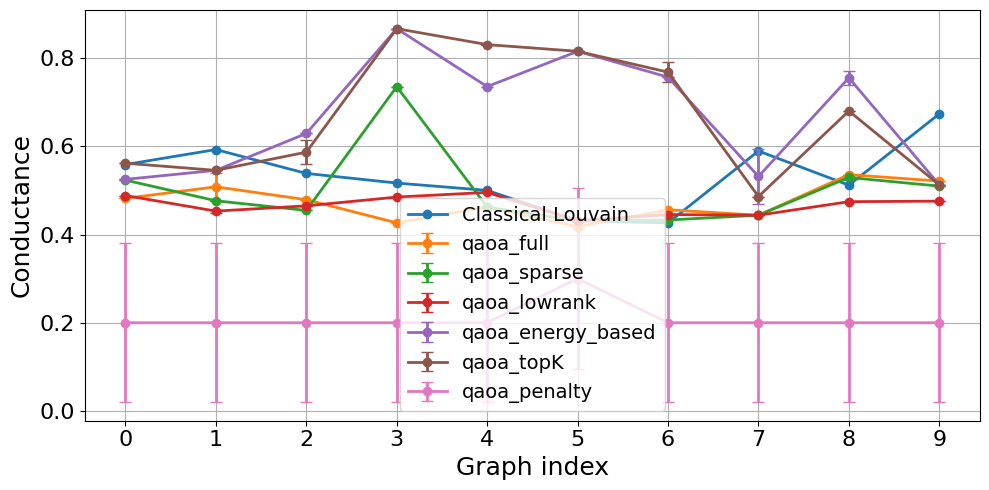

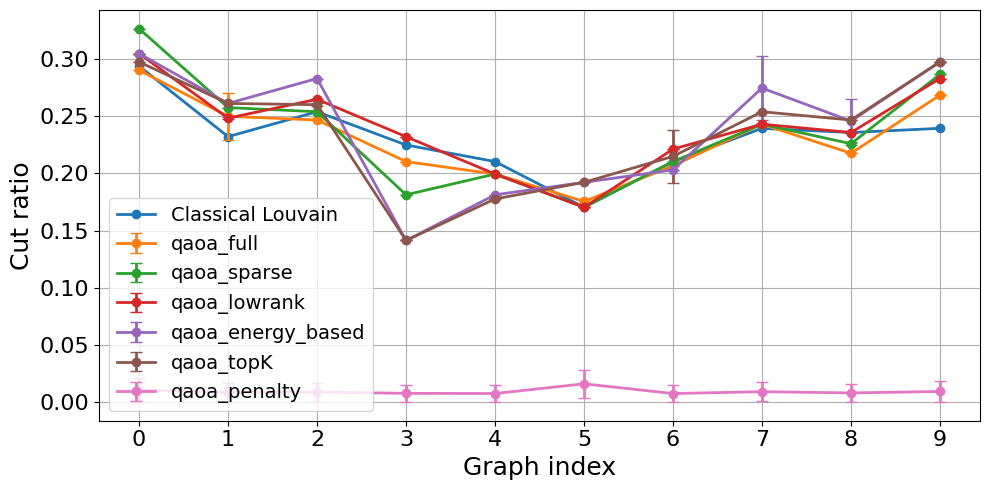

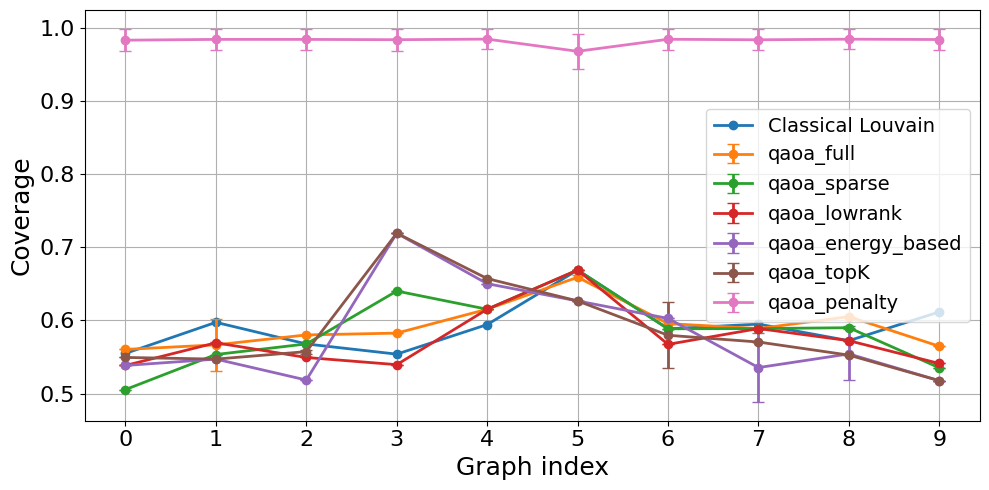

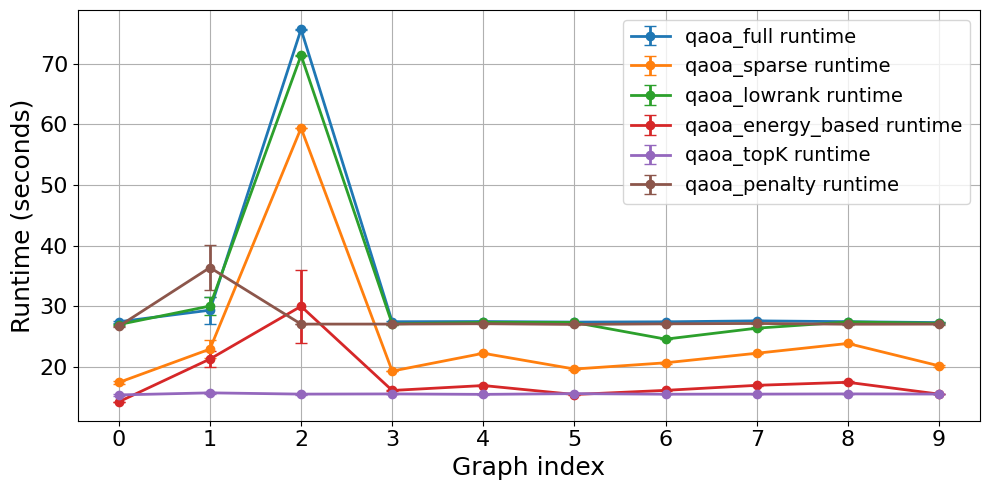

All plots generated.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def plot_metric(metric, ylabel):
    x = np.arange(len(metrics_mean[metric]["classical"]))
    plt.figure(figsize=(10,5))

    # Classical baseline
    plt.plot(x, metrics_mean[metric]["classical"],
             label="Classical Louvain", linewidth=2, marker='o')

    # QAOA methods with CI, no offset
    for m in methods:
        y = metrics_mean[metric][m]
        yerr = metrics_ci[metric][m]

        plt.errorbar(x, y, yerr=yerr,
                     label=m,
                     linewidth=2,
                     marker='o',
                     capsize=4)

    # Formatting
    plt.xlabel("Graph index", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(x, fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_runtime():
    x = np.arange(len(metrics_mean["runtime"]["qaoa_full"]))
    plt.figure(figsize=(10,5))

    # Plot all methods at same x positions
    for m in methods:
        y = metrics_mean["runtime"][m]
        yerr = metrics_ci["runtime"][m]

        plt.errorbar(x, y, yerr=yerr,
                     label=f"{m} runtime",
                     linewidth=2,
                     marker='o',
                     capsize=4)

    plt.xlabel("Graph index", fontsize=18)
    plt.ylabel("Runtime (seconds)", fontsize=18)
    plt.xticks(x, fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_metric("modularity", "Modularity")
plot_metric("conductance", "Conductance")
plot_metric("cut_ratio", "Cut ratio")
plot_metric("coverage", "Coverage")
plot_runtime()

print("All plots generated.")


Pareto Frontiers

In [ ]:
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK"
]

In [ ]:
import numpy as np

avg_mod = {m: np.mean(metrics_mean["modularity"][m]) for m in methods}
avg_cond = {m: np.mean(metrics_mean["conductance"][m]) for m in methods}
avg_cut_ratio = {m: np.mean(metrics_mean["cut_ratio"][m]) for m in methods}
avg_cov = {m: np.mean(metrics_mean["coverage"][m]) for m in methods}
avg_time = {m: np.mean(metrics_mean["runtime"][m]) for m in methods}


In [ ]:
def mean_ci_across_graphs(values, z=1.96):
    values = np.array(values)
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    ci = z * std / np.sqrt(len(values))
    return mean, ci

avg_mod, ci_mod = {}, {}
avg_cond, ci_cond = {}, {}
avg_cut_ratio, ci_cut = {}, {}
avg_cov, ci_cov = {}, {}
avg_time, ci_time = {}, {}

for m in methods:
    avg_mod[m], ci_mod[m] = mean_ci_across_graphs(metrics_mean["modularity"][m])
    avg_cond[m], ci_cond[m] = mean_ci_across_graphs(metrics_mean["conductance"][m])
    avg_cut_ratio[m], ci_cut[m] = mean_ci_across_graphs(metrics_mean["cut_ratio"][m])
    avg_cov[m], ci_cov[m] = mean_ci_across_graphs(metrics_mean["coverage"][m])
    avg_time[m], ci_time[m] = mean_ci_across_graphs(metrics_mean["runtime"][m])

In [ ]:
def pareto_frontier(points, maximize=True):
    """
    Compute Pareto frontier.

    Args:
        points: list of tuples (x, y, label) where
                x = runtime (lower is better)
                y = metric value
        maximize: if True, larger y is better; if False, smaller y is better.

    Returns:
        List of non-dominated points (x, y, label).
    """
    frontier = []
    for p in points:
        px, py, pl = p
        dominated = False
        for q in points:
            qx, qy, ql = q
            if q == p:
                continue

            if maximize:
                # q dominates p if q.runtime <= p.runtime AND q.metric >= p.metric
                if (qx <= px and qy >= py) and (qx < px or qy > py):
                    dominated = True
                    break
            else:
                # For "lower is better" metrics:
                # q dominates p if q.runtime <= p.runtime AND q.metric <= p.metric
                if (qx <= px and qy <= py) and (qx < px or qy < py):
                    dominated = True
                    break

        if not dominated:
            frontier.append(p)

    return frontier

In [ ]:
pts_mod = [(avg_time[m], avg_mod[m], m) for m in methods]
pts_cond = [(avg_time[m], avg_cond[m], m) for m in methods]
pt_cut = [(avg_time[m], avg_cut_ratio[m], m) for m in methods]
pts_cov = [(avg_time[m], avg_cov[m], m) for m in methods]

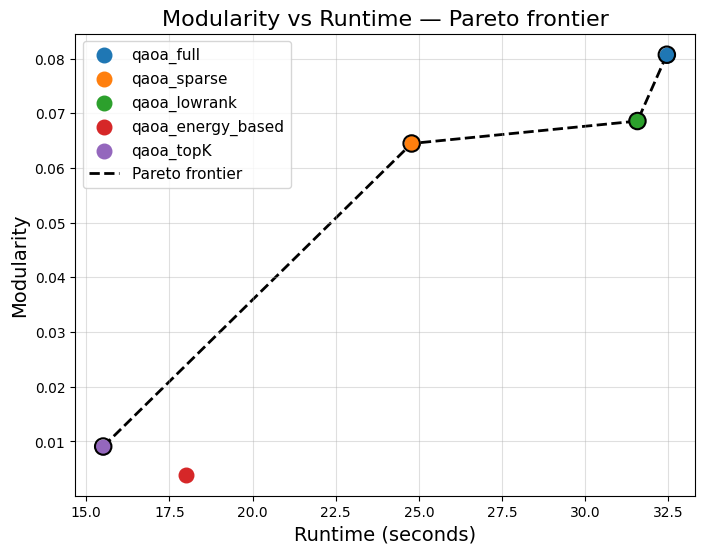

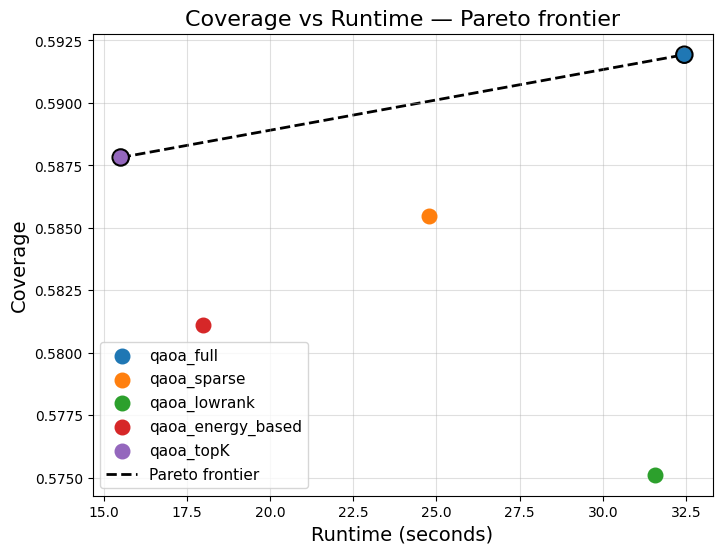

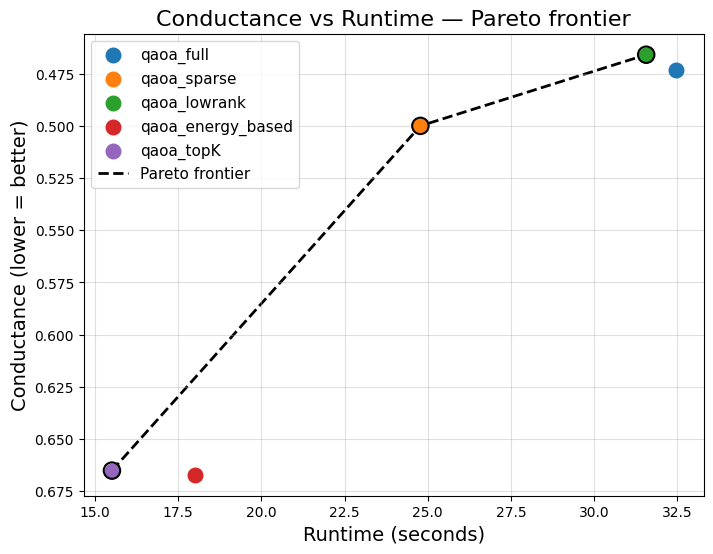

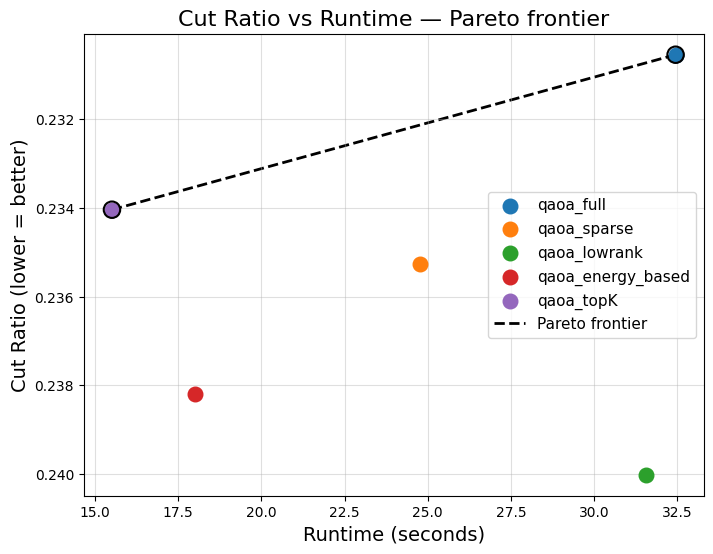

In [ ]:
def plot_metric_frontier(metric_name, metric_dict, ylabel, maximize=True, flip_y=False):
    """
    Generic Pareto plot: runtime (x) vs metric (y).
    If maximize=False, smaller y is better (conductance, cut ratio).
    """
    pts = [(avg_time[m], metric_dict[m], m) for m in methods]
    fr = pareto_frontier(pts, maximize=maximize)

    # Sort frontier by runtime for plotting the connecting line
    fr_sorted = sorted(fr, key=lambda p: p[0])

    plt.figure(figsize=(8,6))

    # plot all methods
    for m in methods:
        plt.scatter(avg_time[m], metric_dict[m], s=110, label=m, zorder=2)

    # plot frontier line and frontier points (without labels)
    if len(fr_sorted) >= 2:
        plt.plot([p[0] for p in fr_sorted],
                 [p[1] for p in fr_sorted],
                 '--', color='black', linewidth=2, zorder=1, label='Pareto frontier')
        plt.scatter([p[0] for p in fr_sorted],
                    [p[1] for p in fr_sorted],
                    s=140, facecolors='none', edgecolors='black', linewidths=1.5, zorder=3)

    plt.xlabel("Runtime (seconds)", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(f"{metric_name} vs Runtime — Pareto frontier", fontsize=16)
    plt.grid(True, alpha=0.4)
    plt.legend(fontsize=11)

    if flip_y:
        plt.gca().invert_yaxis()

    plt.show()


# -------------------------
# Example calls:
# -------------------------
# maximize=True (higher is better)
plot_metric_frontier("Modularity", avg_mod, "Modularity", maximize=True, flip_y=False)
plot_metric_frontier("Coverage",  avg_cov, "Coverage",  maximize=True, flip_y=False)

# maximize=False (lower is better) — draw frontier using lower-is-better dominance
plot_metric_frontier("Conductance", avg_cond, "Conductance (lower = better)", maximize=False, flip_y=True)
plot_metric_frontier("Cut Ratio",   avg_cut_ratio, "Cut Ratio (lower = better)",     maximize=False, flip_y=True)

# Experiment 3: noise test

In [ ]:
num_nodes_red = 11

In [ ]:
# ------------------ SELECT SINGLE GRAPH ------------------

# Choose which index in top_dense_graphs to run
target_idx = 9   # change this (0 → first, 1 → second, etc.)

# Create a temporary list with only one graph
overall_top_dense_graphs = top_dense_graphs
top_dense_graphs = [overall_top_dense_graphs[target_idx]]

print("Running only graph:", top_dense_graphs)

Running only graph: [46]


In [ ]:
# ------------------ NOISE CONFIG -------------------
noise_strength = 0.01

# === stress test ===

import community.community_louvain as community_louvain
from pennylane import numpy as np
import pennylane as qml
import pickle
import time

# ------------------ CONFIG -------------------
num_layers = 2
n_steps = 5

threshold = 0.3
lowrank_k = 2
topK_ratio = 0.5
penalty_mu = 0.4
penalty_S = 0
energy_ratio = 0.7



# ------------------ METHODS -------------------
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK",
    "qaoa_penalty"
]

metrics = {
    "modularity": {m: [] for m in ["classical"] + methods},
    "conductance": {m: [] for m in ["classical"] + methods},
    "cut_ratio": {m: [] for m in ["classical"] + methods},
    "coverage": {m: [] for m in ["classical"] + methods},
    "runtime": {m: [] for m in methods},
}

# ------------------ SEEDS -------------------
seeds = list(range(5))

# ======================================
# QAOA runner with noise
# ======================================
def build_qaoa_runner(G, cost_h, mixer_h, n_wires):

    # ✅ IMPORTANT: noisy simulator
    dev = qml.device("default.mixed", wires=n_wires)

    def U_C(gamma):
        qml.templates.ApproxTimeEvolution(cost_h, gamma, 1)

    def U_B(beta):
        qml.templates.ApproxTimeEvolution(mixer_h, beta, 1)

    def apply_noise(wires):
        for w in wires:
            qml.DepolarizingChannel(noise_strength, wires=w)

    @qml.qnode(dev)
    def circuit(gammas, betas, return_probs=False):

        # Initial layer
        for w in range(n_wires):
            qml.Hadamard(wires=w)
            apply_noise([w])

        # QAOA layers
        for gamma, beta in zip(gammas, betas):
            U_C(gamma)
            apply_noise(range(n_wires))

            U_B(beta)
            apply_noise(range(n_wires))

        if return_probs:
            return qml.probs(wires=range(n_wires))
        return qml.expval(cost_h)

    def objective(params):
        return -circuit(params[0], params[1])

    def run_qaoa(seed):
        np.random.seed(seed)

        params = np.array(0.01 * np.random.rand(2, num_layers), requires_grad=True)
        opt = qml.AdagradOptimizer(stepsize=0.5)

        t0 = time.time()
        for _ in range(n_steps):
            params = opt.step(objective, params)
        runtime = time.time() - t0

        probs = circuit(params[0], params[1], return_probs=True)
        return probs, runtime

    return run_qaoa

In [ ]:
# Comment this if first run
#metrics = pickle.load(open("metrics_dense_subgraphs_top10_noise.pkl", "rb"))
# ------------------ FIX: ensure noisy keys exist ------------------
for m in methods:
    noisy_key = m + "_noisy"

    for metric_name in ["modularity", "conductance", "cut_ratio", "coverage"]:
        if noisy_key not in metrics[metric_name]:
            metrics[metric_name][noisy_key] = []

    if noisy_key not in metrics["runtime"]:
        metrics["runtime"][noisy_key] = []

for graph_id in top_dense_graphs:

    print(f"\n================== GRAPH {graph_id} ==================")

    G = pickle.load(open(path + f"Graph_{graph_id}", "rb")).to_undirected()
    G = reduce_graph(G, target_size=num_nodes_red)

    # Classical Louvain
    part = community_louvain.best_partition(G)
    part = binary_partition(part, G)

    metrics["modularity"]["classical"].append(community_louvain.modularity(part, G))
    metrics["conductance"]["classical"].append(compute_conductance(G, part))
    metrics["cut_ratio"]["classical"].append(compute_cut_ratio(G, part))
    metrics["coverage"]["classical"].append(compute_coverage(G, part))

    # qubit mapping
    node_to_qubit = {n: i for i, n in enumerate(G.nodes())}
    qubit_to_node = {i: n for n, i in node_to_qubit.items()}
    n_wires = G.number_of_nodes()

    mixer_h = qml.Hamiltonian([1.0]*n_wires, [qml.PauliX(i) for i in range(n_wires)])

    # define cost Hamiltonians
    quantum_costs = {
        "qaoa_full":    modularity_hamiltonian(G),
        "qaoa_sparse":  modularity_hamiltonian_sparsified(G, tau=threshold),
        "qaoa_lowrank": modularity_hamiltonian_lowrank(G, k_rank=lowrank_k),
        "qaoa_energy_based": modularity_hamiltonian_energy_preserving(G, energy_ratio=energy_ratio),
        "qaoa_topK":    modularity_hamiltonian_topK(G, keep_ratio=topK_ratio),
        "qaoa_penalty": modularity_hamiltonian_with_penalty(G, mu=penalty_mu, S=penalty_S),
    }

    for method, cost_h in quantum_costs.items():

        method_name = method + "_noisy"   # ✅ consistent naming
        print(f" → Running {method_name} QAOA...")
        runner = build_qaoa_runner(G, cost_h, mixer_h, n_wires)

        # store per-seed results
        mod_list, cond_list, cut_list, cov_list, runtime_list = [], [], [], [], []

        for s in seeds:
            probs, runtime = runner(s)
            runtime_list.append(runtime)

            best = max([(format(i, f"0{n_wires}b"), p) for i, p in enumerate(probs)],
                   key=lambda x: x[1])[0]

            part_q = {qubit_to_node[q]: int(bit) for q, bit in enumerate(best)}

            mod_list.append(compute_modularity_safe(G, part_q))
            cond_list.append(compute_conductance(G, part_q))
            cut_list.append(compute_cut_ratio(G, part_q))
            cov_list.append(compute_coverage(G, part_q))

        # store lists (NOT scalars)
        metrics["runtime"][method_name].append(runtime_list)
        metrics["modularity"][method_name].append(mod_list)
        metrics["conductance"][method_name].append(cond_list)
        metrics["cut_ratio"][method_name].append(cut_list)
        metrics["coverage"][method_name].append(cov_list)

pickle.dump(metrics, open("metrics_dense_subgraphs_top10_noise.pkl", "wb"))
print("Saved metrics for densest reduced graphs.")



================== GRAPH 46 ==================
Sparsification: kept 26 ZZ terms out of 55
Low-rank projection: kept 26 ZZ terms from rank-2 spectral model
Energy sparsification: kept 18 ZZ terms, energy covered: 71.49%
Top-K sparsification: kept 27 terms out of 55
Penalty Hamiltonian: kept 55/55 ZZ terms and 0/11 Z terms (mu=0.4, S=0)
 → Running qaoa_full_noisy QAOA...


 → Running qaoa_sparse_noisy QAOA...
 → Running qaoa_lowrank_noisy QAOA...
 → Running qaoa_energy_based_noisy QAOA...
 → Running qaoa_topK_noisy QAOA...
 → Running qaoa_penalty_noisy QAOA...
Saved metrics for densest reduced graphs.


In [ ]:
def plot_noise_comparison(metric, ylabel):
    x = range(len(metrics_mean[metric]["classical"]))
    plt.figure(figsize=(10,5))

    for m in methods:
        plt.plot(x, metrics_mean[metric][m], label=f"{m} (ideal)")
        plt.plot(x, metrics_mean[metric][m+"_noisy"], linestyle="--", label=f"{m} (noisy)")

    plt.xlabel("Graph index")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

Noisy-noisless plots

In [ ]:
import pickle

metrics_ideal = pickle.load(open("metrics_dense_subgraphs_top10_noiseless.pkl", "rb"))
metrics_noisy = pickle.load(open("metrics_dense_subgraphs_top10_noise.pkl", "rb"))

In [ ]:
metrics_noisy

{'modularity': {'classical': [0.015407986111111077,
   0.019199567333693907,
   0.03061224489795908,
   0.016070124178232337,
   0.04499999999999996,
   0.0,
   0.03418803418803423,
   0.020551649540292052,
   0.06804733727810654,
   0.02040289256198355],
  'qaoa_full': [],
  'qaoa_sparse': [],
  'qaoa_lowrank': [],
  'qaoa_energy_based': [],
  'qaoa_topK': [],
  'qaoa_penalty': [],
  'qaoa_full_noisy': [[0.01540798611111116,
    -0.021701388888888853,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116],
   [0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144],
   [0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134],
   [0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776],
   [0.04500000000000001,
    0.04500000000000001,
    0.04500000000000001,
    

In [ ]:
def clean_metrics(metrics):
    cleaned = {}

    for metric_name, methods_dict in metrics.items():
        cleaned[metric_name] = {}

        for m, values in methods_dict.items():
            if len(values) > 0:   # keep only non-empty
                cleaned[metric_name][m] = values

    return cleaned

#metrics_ideal = clean_metrics(metrics_ideal)
metrics_noisy = clean_metrics(metrics_noisy)

In [ ]:
metrics_all = {}

for metric in metrics_ideal.keys():
    metrics_all[metric] = {}

    # ideal
    for m, v in metrics_ideal[metric].items():
        metrics_all[metric][m] = v

    # noisy
    for m, v in metrics_noisy[metric].items():
        metrics_all[metric][m] = v

In [ ]:
import numpy as np

metrics_mean = {}
metrics_std = {}
metrics_ci = {}

def mean_ci(values):
    values = np.array(values)
    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    ci = 1.96 * std / np.sqrt(len(values)) if len(values) > 1 else 0.0
    return mean, std, ci

for metric in metrics_all.keys():
    metrics_mean[metric] = {}
    metrics_std[metric] = {}
    metrics_ci[metric] = {}

    for m, graph_vals in metrics_all[metric].items():

        means = []
        stds = []
        cis = []

        for vals in graph_vals:
            # classical = scalar, QAOA = list
            if isinstance(vals, list):
                mean, std, ci = mean_ci(vals)
            else:
                mean, std, ci = vals, 0.0, 0.0

            means.append(mean)
            stds.append(std)
            cis.append(ci)

        metrics_mean[metric][m] = means
        metrics_std[metric][m] = stds
        metrics_ci[metric][m] = cis

In [ ]:
methods = [
    "qaoa_full",
    "qaoa_sparse",
    "qaoa_lowrank",
    "qaoa_energy_based",
    "qaoa_topK",
    "qaoa_penalty"
]

methods_noisy = [m + "_noisy" for m in methods]

In [ ]:
metrics_noisy

{'modularity': {'classical': [0.015407986111111077,
   0.019199567333693907,
   0.03061224489795908,
   0.016070124178232337,
   0.04499999999999996,
   0.0,
   0.03418803418803423,
   0.020551649540292052],
  'qaoa_full_noisy': [[0.01540798611111116,
    -0.021701388888888853,
    0.01540798611111116,
    0.01540798611111116,
    0.01540798611111116],
   [0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144,
    0.03569497025419144],
   [0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134,
    0.030612244897959134],
   [0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776,
    0.037983929875821776],
   [0.04500000000000001,
    0.04500000000000001,
    0.04500000000000001,
    0.04500000000000001,
    0.04500000000000001],
   [0.0, 0.0, 0.0, 0.0, 0.0],
   [0.034188034188034164,
    0.034188034188034164,
    0.034188034188034164,
    0.03418803418803416

In [ ]:
for m in methods:
    if m in metrics_mean[metric]:
        print(m, len(metrics_mean[metric][m]))
    if m+"_noisy" in metrics_mean[metric]:
        print(m+"_noisy", len(metrics_mean[metric][m+"_noisy"]))

qaoa_full 10
qaoa_full_noisy 10
qaoa_sparse 10
qaoa_sparse_noisy 10
qaoa_lowrank 10
qaoa_lowrank_noisy 10
qaoa_energy_based 10
qaoa_energy_based_noisy 10
qaoa_topK 10
qaoa_topK_noisy 10
qaoa_penalty 10
qaoa_penalty_noisy 10


In [ ]:
label_map = {
    "qaoa_full": "F",
    "qaoa_sparse": "S",
    "qaoa_lowrank": "L",
    "qaoa_energy_based": "E",
    "qaoa_topK": "K",
    "qaoa_penalty": "P"
}

Degradation plot

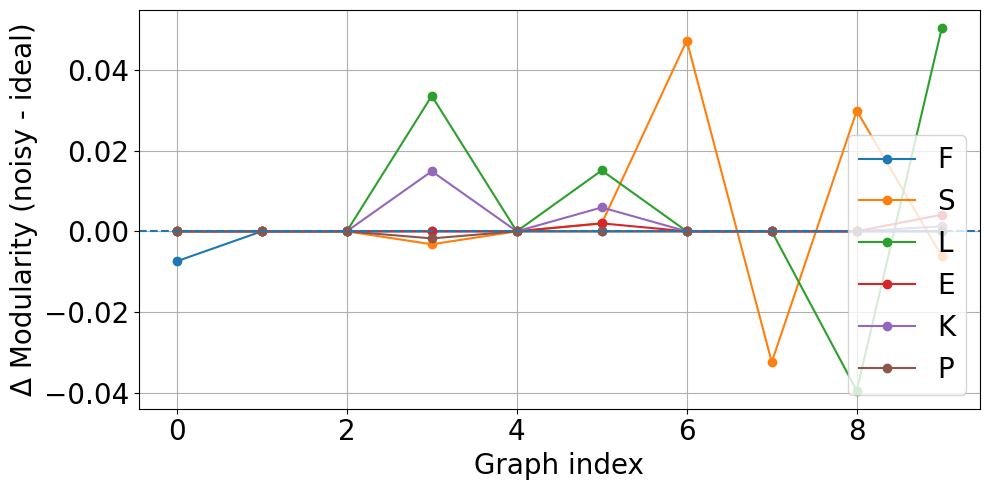

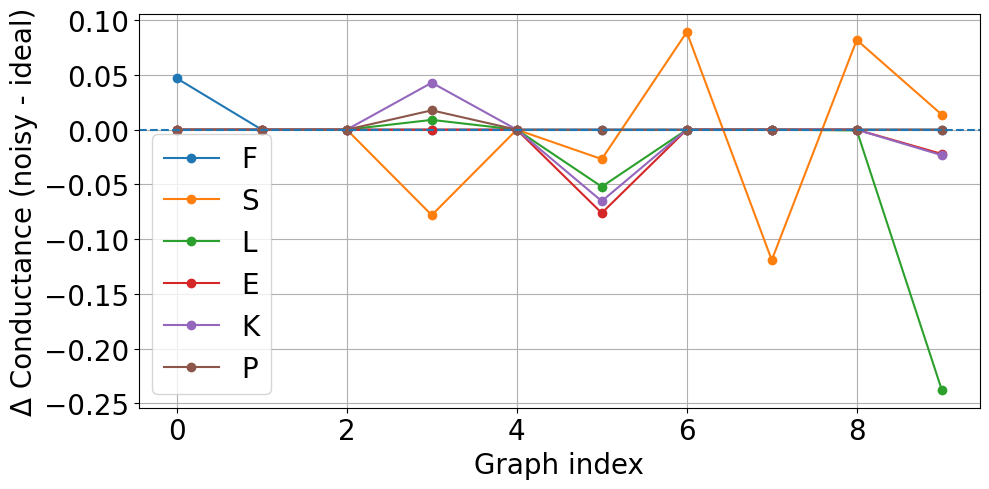

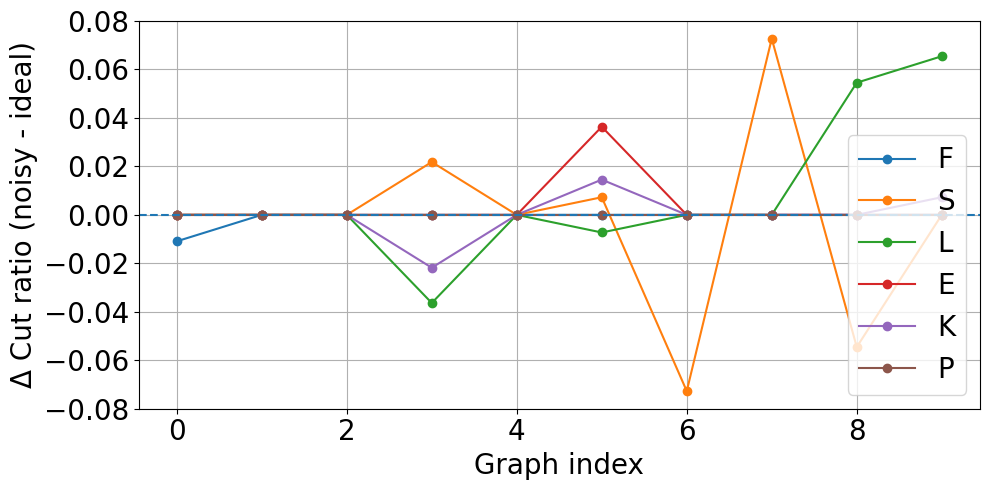

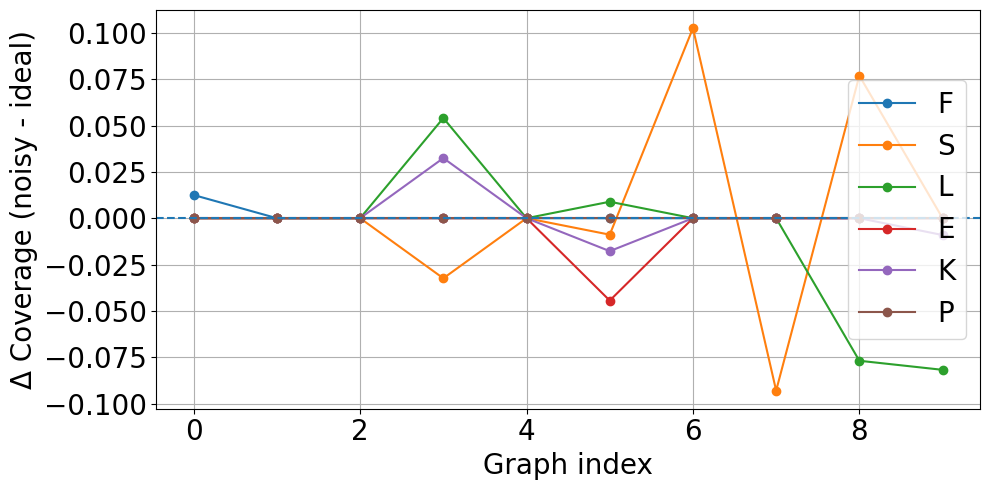

In [ ]:
def plot_degradation(metric, ylabel):
    x = range(len(metrics_mean[metric]["classical"]))
    plt.figure(figsize=(10,5))

    for m in methods:
        if m in metrics_mean[metric] and m+"_noisy" in metrics_mean[metric]:

            ideal = np.array(metrics_mean[metric][m])
            noisy = np.array(metrics_mean[metric][m+"_noisy"])

            delta = noisy - ideal

            lbl = label_map.get(m, m)  # fallback to full name if missing

            plt.plot(x, delta, marker='o', label=lbl)

    plt.axhline(0, linestyle="--")
    plt.xlabel("Graph index", fontsize=20)
    plt.ylabel(f"Δ {ylabel} (noisy - ideal)", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_degradation("modularity", "Modularity")
plot_degradation("conductance", "Conductance")
plot_degradation("cut_ratio", "Cut ratio")
plot_degradation("coverage", "Coverage")